In [ ]:
# -----------------------------------------------------------------------------
# Install Libraries and Dependencies
# -----------------------------------------------------------------------------
!pip -q install \
  langgraph==0.2.39 \
  langchain==0.3.14 \
  langchain-core==0.3.29 \
  langchain-community==0.3.14 \
  langsmith==0.1.147 \
  openai==1.59.6 \
  langchain-openai==0.2.14 \
  pydantic==2.10.4 \
  pandas==2.2.3 \
  numpy==2.2.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.5/113.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.6/411.6 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.8/431.8 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

22:46:51 | INFO     | EHR_Assistant | 🚀 Starting EHR Assistant...
22:46:51 | INFO     | EHR_Assistant | └── 🔒 Authenticating Google Colab session...
22:46:51 | INFO     | EHR_Assistant | └── ✅ Authentication successful.
22:46:51 | INFO     | EHR_Assistant | └── ⏳ Loading data from Google Drive...
22:46:51 | INFO     | EHR_Assistant | └── ⚙️ Loading configuration...
22:46:51 | INFO     | EHR_Assistant | └── 🔑 API credentials successfully loaded.
22:46:51 | INFO     | EHR_Assistant | └── 📂 Loading reference CSV datasets...
22:46:51 | INFO     | EHR_Assistant | └── ✅ Loaded 'safety_rules' (10 rows)
22:46:51 | INFO     | EHR_Assistant | └── ✅ Loaded 'sources_catalog' (20 rows)
22:46:51 | INFO     | EHR_Assistant | └── ✅ Loaded 'med_education' (30 rows)
22:46:51 | INFO     | EHR_Assistant | └── ✅ Loaded 'lab_explanations' (30 rows)
22:46:51 | INFO     | EHR_Assistant | └── 📁 Connecting to SQLite database...
22:46:51 | INFO     | EHR_Assistant | └── 💾 Database connected. Tables found: patien

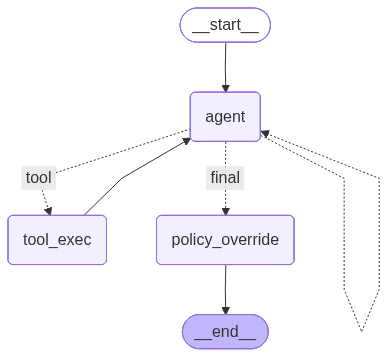


------------------------------------------------------------------------------------------------------------------------
22:46:51 | INFO     | EHR_Assistant | └── 🧪 RUNNING CASE: (Patient: POO1)
22:46:51 | INFO     | EHR_Assistant | └── 🔍 User Query: What does my Hemoglobin A1c result mean?

------------------------------------------------------------------------------------------------------------------------
22:46:55 | INFO     | EHR_Assistant | └── ✨ AI MED ASSISTANT REPLY FOR POO1:
The Hemoglobin A1c (A1c) test reflects your average blood sugar levels over the past 2–3 months. It is an important tool for monitoring diabetes and assessing long-term blood sugar control.

### Key Points:
- **Why It Matters**: It helps in monitoring diabetes and understanding long-term blood sugar control.
- **Common Reasons for High Levels**: High A1c levels can indicate diabetes or prediabetes. Certain medical conditions may also affect the results.
- **Common Reasons for Low Levels**: Low A1c level

In [ ]:
"""
================================================================================
Script Name     : AI_Project_2_JasonWayneMcGinty.py
University      : University of Texas at Austin
Program         : AI Agents in Business Applications
Author          : Jason Wayne McGinty
Date Created    : 2026-04-28
Last Modified   : 2026-05-17
Version         : 2.1.0 (ReAct Tracing & Safety Guardrails Enforced)
Description     : Professional EHR Assistant Agent utilizing LangGraph for complex
                  reasoning (ReAct). Features include JSON-based Config loading,
                  GPT-4o-mini integration, a robust SQLite Toolkit Factory,
                  custom Safety/Policy guardrail nodes, and execution visualization.

AI-Enabled      : Developed with the assistance of Gemini AI.

References      : McGinty, J. (2026). Learners_Notebook_Full_Code_JasonWayneMcGinty.ipynb
                  Code fragment reuse. University of Texas at Austin.

                : University of Texas at Austin. (2026). Project 2 - AI-powered EHR Assistant - Full-code Notebook.ipynb
                  Code fragments from problem statement.
================================================================================
"""

import os
import re
import sys
import logging
import sqlite3
import json
from pathlib import Path
from typing import Annotated, Sequence, TypedDict, Dict, Callable, Union, List, Optional, Any

import pandas as pd
import numpy as np
from google.colab import drive, auth
from IPython.display import Image, display

# --- LangChain & LangGraph Core Imports ---
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage, ToolMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool

# -----------------------------------------------------------------------------
# Utility Functions
# -----------------------------------------------------------------------------
def norm_text(s: str) -> str:
    """Normalizes text by removing extra whitespace and converting to lowercase for robust matching."""
    return re.sub(r"\s+", " ", str(s).strip().lower())

def to_json(obj: Any) -> str:
    """Safely converts Python objects/dictionaries into JSON strings for LLM consumption."""
    return json.dumps(obj, ensure_ascii=False, default=str)

# -----------------------------------------------------------------------------
# Logging Configuration
# -----------------------------------------------------------------------------
class LogManager:
    """
    Centralized logging configuration.
    Ensures standard formatting across the application to track agent execution.
    """
    @staticmethod
    def get_logger(name: str, level=logging.INFO) -> logging.Logger:
        logger = logging.getLogger(name)
        logger.setLevel(level)
        logger.propagate = False

        if not logger.handlers:
            console_handler = logging.StreamHandler(sys.stdout)
            formatter = logging.Formatter(
                fmt='%(asctime)s | %(levelname)-8s | %(name)s | %(message)s',
                datefmt='%H:%M:%S'
            )
            console_handler.setFormatter(formatter)
            logger.addHandler(console_handler)
        return logger

log = LogManager.get_logger("EHR_Assistant")

# -----------------------------------------------------------------------------
# Resource & File Management
# -----------------------------------------------------------------------------
class DriveResource:
    """Base class handling authentication and mounting of Google Drive resources."""
    def __init__(self):
        self.mount_point = Path('/content/drive')
        self.drive_root = self.mount_point / 'MyDrive'
        self._ensure_drive_mounted()

    def _ensure_drive_mounted(self):
        if not self.drive_root.exists():
            log.info("└── 📂 Mounting Google Drive...")
            try:
                drive.mount(str(self.mount_point))
            except Exception as e:
                log.error(f"└── ❌ Mount failed: {e}")
                raise

class FileLoader(DriveResource):
    """Handles parsing and ingestion of static reference files (JSON/CSV)."""
    def read(self, relative_path: str) -> Optional[Union[pd.DataFrame, Dict]]:
        full_path = self.drive_root / relative_path
        if not full_path.exists():
            log.error(f"└── ❌ File not found: {full_path}")
            return None

        ext = full_path.suffix.lower()
        try:
            if ext == '.json':
                with open(full_path, 'r') as f:
                    return json.load(f)
            elif ext == '.csv':
                return pd.read_csv(full_path)

            log.error(f"└── ❌ Unsupported file extension: {ext}")
            return None
        except Exception as e:
            log.error(f"└── ❌ Error reading {full_path}: {e}")
            return None

class DatabaseReader:
    """
    Interface for secure SQLite database operations.
    Utilizes parameterized queries to prevent SQL injection vulnerabilities.
    """
    def __init__(self, db_path: Path):
        self.db_path = db_path
        if not self.db_path.exists():
            log.error(f"└── ❌ Database missing at: {self.db_path}")
            raise FileNotFoundError(f"Database missing: {self.db_path}")

    def get_table_names(self) -> List[str]:
        query = "SELECT name FROM sqlite_master WHERE type='table';"
        with sqlite3.connect(self.db_path) as conn:
            cursor = conn.cursor()
            cursor.execute(query)
            return [row[0] for row in cursor.fetchall()]

    def read_query(self, query: str, params: tuple = ()) -> Optional[pd.DataFrame]:
        """Executes a SELECT query securely using tuple parameters."""
        with sqlite3.connect(self.db_path) as conn:
            return pd.read_sql_query(query, conn, params=params)

# -----------------------------------------------------------------------------
# Agent Logic & Tool Factory
# -----------------------------------------------------------------------------
class EHRToolkit:
    """
    A factory class that generates tools for the LLM to interact with the EHR database
    and static educational reference datasets.
    """
    def __init__(self, db_reader: DatabaseReader, datasets: Dict[str, pd.DataFrame]):
        self.db_reader = db_reader
        self.datasets = datasets

    def _sql_query(self, q: str, params: tuple = ()) -> List[Dict[str, Any]]:
        """Helper to convert the DataFrame output of db_reader into a list of dicts for JSON conversion."""
        df = self.db_reader.read_query(q, params)
        if df is not None and not df.empty:
            return df.to_dict(orient="records")
        return []

    def get_tools(self) -> list:
        """Returns the compiled list of @tool decorated functions bound to the active database."""

        @tool("get_patient_profile")
        def get_patient_profile(patient_id: str) -> str:
            """Retrieve a patient's basic profile from the SQLite `patients` table."""
            rows = self._sql_query("""
                SELECT patient_id, first_name, last_name, birth_year, sex_at_birth,
                       preferred_language, health_literacy_level, timezone, created_at
                FROM patients
                WHERE patient_id = ?
            """, (patient_id,))
            return to_json(rows[0] if rows else {"error": f"Patient {patient_id} not found"})

        @tool("list_patient_encounters")
        def list_patient_encounters(patient_id: str, limit: int = 5) -> str:
            """Fetch a patient's most recent encounters from the SQLite `encounters` table."""
            limit = max(1, min(int(limit), 7)) # Hard cap at 7 to prevent token overflow
            rows = self._sql_query("""
                SELECT encounter_id, encounter_date, encounter_type, reason_for_visit,
                       diagnosis_summary, provider_specialty, followup_instructions, care_team_contact
                FROM encounters
                WHERE patient_id = ?
                ORDER BY encounter_date DESC
                LIMIT ?
            """, (patient_id, limit))
            return to_json(rows)

        @tool("get_recent_clinical_note")
        def get_recent_clinical_note(patient_id: str, note_type: str = "visit_note") -> str:
            """Retrieve the most recent clinical note for a patient."""
            if note_type not in ("visit_note", "discharge_summary"):
                note_type = "visit_note"
            rows = self._sql_query("""
                SELECT note_id, encounter_id, patient_id, note_type, note_text, created_at, author_role
                FROM clinical_notes
                WHERE patient_id = ? AND note_type = ?
                ORDER BY created_at DESC
                LIMIT 1
            """, (patient_id, note_type))
            return to_json(rows[0] if rows else {"error": f"No {note_type} found for patient {patient_id}"})

        @tool("get_labs")
        def get_labs(patient_id: str, test_name: Optional[str] = None, limit: int = 10) -> str:
            """Fetch recent laboratory results for a patient."""
            limit = max(1, min(int(limit), 15))
            if test_name:
                rows = self._sql_query("""
                    SELECT lab_result_id, ordered_date, result_date, loinc_code, test_name,
                           value_numeric, value_text, unit, ref_range_low, ref_range_high, flag, lab_source
                    FROM labs
                    WHERE patient_id = ? AND lower(test_name) = lower(?)
                    ORDER BY result_date DESC
                    LIMIT ?
                """, (patient_id, test_name, limit))
            else:
                rows = self._sql_query("""
                    SELECT lab_result_id, ordered_date, result_date, loinc_code, test_name,
                           value_numeric, value_text, unit, ref_range_low, ref_range_high, flag, lab_source
                    FROM labs
                    WHERE patient_id = ?
                    ORDER BY result_date DESC
                    LIMIT ?
                """, (patient_id, limit))
            return to_json(rows)

        @tool("get_medications")
        def get_medications(patient_id: str, status: str = "active") -> str:
            """Retrieve a patient's medication list from the SQLite `medications` table."""
            if status not in ("active", "stopped", "all"):
                status = "active"

            if status == "all":
                rows = self._sql_query("""
                    SELECT med_id, rxnorm_code, med_name, dose, route, frequency,
                           start_date, end_date, status, indication, prescriber_specialty
                    FROM medications
                    WHERE patient_id = ?
                    ORDER BY status DESC, start_date DESC
                """, (patient_id,))
            else:
                rows = self._sql_query("""
                    SELECT med_id, rxnorm_code, med_name, dose, route, frequency,
                           start_date, end_date, status, indication, prescriber_specialty
                    FROM medications
                    WHERE patient_id = ? AND status = ?
                    ORDER BY start_date DESC
                """, (patient_id, status))
            return to_json(rows)

        @tool("get_allergies")
        def get_allergies(patient_id: str) -> str:
            """Retrieve a patient's recorded allergies from the SQLite `allergies` table."""
            rows = self._sql_query("""
                SELECT allergy_id, substance, reaction, severity, recorded_date
                FROM allergies
                WHERE patient_id = ?
                ORDER BY recorded_date DESC
            """, (patient_id,))
            return to_json(rows)

        @tool("lookup_lab_education")
        def lookup_lab_education(test_name: str) -> str:
            """Retrieve patient-friendly education content for a lab test."""
            tn = norm_text(test_name)
            df = self.datasets.get("lab_explanations")
            if df is None: return to_json({"error": "Lab education data unavailable."})

            df = df.copy()
            df["_k"] = df["test_name_normalized"].astype(str).map(norm_text)
            hit = df[df["_k"] == tn]
            if hit.empty:
                hit = df[df["_k"].str.contains(tn, na=False)]

            if hit.empty: return to_json({"error": f"No lab education found for '{test_name}'"})
            row = hit.iloc[0].drop(labels=["_k"]).to_dict()
            return to_json(row)

        @tool("lookup_medication_education")
        def lookup_medication_education(med_name: str) -> str:
            """Retrieve patient-friendly education content for a medication."""
            mn = norm_text(med_name)
            df = self.datasets.get("med_education")
            if df is None: return to_json({"error": "Medication education data unavailable."})

            df = df.copy()
            df["_k"] = df["med_name_normalized"].astype(str).map(norm_text)
            hit = df[df["_k"] == mn]
            if hit.empty:
                hit = df[df["_k"].str.contains(mn, na=False)]

            if hit.empty: return to_json({"error": f"No medication education found for '{med_name}'"})
            row = hit.iloc[0].drop(labels=["_k"]).to_dict()
            return to_json(row)

        @tool("policy_route")
        def policy_route(user_text: str) -> str:
            """
            Evaluates the user query against the safety_rules dataset.
            Returns an action decision (e.g., escalate_emergency) to govern the agent's behavior.
            """
            df = self.datasets.get("safety_rules")
            if df is None: return to_json({"action": "answer", "matched_rules": []})

            text = norm_text(user_text)
            rules = df.to_dict(orient="records")
            matches = [r for r in rules if norm_text(r.get("pattern_or_topic", "")) in text]

            if not matches:
                return to_json({"action": "answer", "matched_rules": []})

            # Sort by severity priority
            priority = {"escalate_emergency": 3, "escalate_clinician": 2, "refuse": 1, "answer": 0}
            matches_sorted = sorted(matches, key=lambda r: priority.get(r.get("agent_action", "answer"), 0), reverse=True)
            best = matches_sorted[0]

            out = {
                "action": best["agent_action"],
                "rule_id": best["rule_id"],
                "template": best["standard_response_template"],
                "matched_rules": [{"rule_id": m["rule_id"], "action": m["agent_action"], "topic": m["pattern_or_topic"]} for m in matches_sorted]
            }
            return to_json(out)

        return [
            get_patient_profile, list_patient_encounters, get_recent_clinical_note,
            get_labs, get_medications, get_allergies, lookup_lab_education,
            lookup_medication_education, policy_route
        ]

# -----------------------------------------------------------------------------
# LangGraph Architecture & Custom Safety Nodes
# -----------------------------------------------------------------------------
class AgentState(TypedDict):
    """
    Defines the memory state passed between LangGraph nodes.
    The `add_messages` reducer automatically appends new messages to the history list.
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]
    patient_id: str                   # Strict security scope for the current execution
    citations: List[Dict[str, Any]]   # Track provenance of provided education materials
    errors: List[str]
    decision: str                     # Driven by the policy_route tool
    policy_template: Optional[str]
    draft_answer: Optional[str]
    final_answer: Optional[str]

# Tools that MUST automatically inject the scoped patient_id to prevent cross-patient data access
PATIENT_SCOPED_TOOLNAMES = {
    "get_patient_profile", "list_patient_encounters", "get_recent_clinical_note",
    "get_labs", "get_medications", "get_allergies",
}

def _cap_limit(args: Dict[str, Any], max_limit: int = 10) -> Dict[str, Any]:
    """Safety bounds for database limits to prevent token exhaustion."""
    out = dict(args)
    if "limit" in out and out["limit"] is not None:
        try:
            out["limit"] = min(int(out["limit"]), max_limit)
        except Exception:
            out["limit"] = max_limit
    return out

def tool_exec_node(state: AgentState) -> Dict[str, Any]:
    """
    Custom LangGraph Node: Executes tools called by the LLM.
    Enforces patient scoping, bounds limits, and catches errors.
    """
    last = state["messages"][-1]
    tool_calls = getattr(last, "tool_calls", []) or []
    tool_map = {t.name: t for t in TOOLS}

    # Start empty; LangGraph's reducer will append these to the main history automatically
    new_messages = []
    new_citations = list(state.get("citations", []))
    new_errors = list(state.get("errors", []))

    for tc in tool_calls:
        name = tc.get("name")
        args = tc.get("args", {}) or {}
        tool_id = tc.get("id")

        if name not in tool_map:
            new_errors.append(f"Blocked unknown tool call: {name}")
            new_messages.append(ToolMessage(content=f"Blocked unknown tool: {name}", name=name or "unknown", tool_call_id=tool_id))
            continue

        # Force the contextual patient_id (Security Control)
        if name in PATIENT_SCOPED_TOOLNAMES:
            args["patient_id"] = state["patient_id"]

        if name in {"get_labs", "list_patient_encounters"}:
            args = _cap_limit(args, max_limit=10)

        try:
            result_str = tool_map[name].invoke(args)
            if not isinstance(result_str, str):
                result_str = json.dumps(result_str, ensure_ascii=False, default=str)
            new_messages.append(ToolMessage(content=result_str, name=name, tool_call_id=tool_id))

        except Exception as e:
            err = f"{name} failed: {e}"
            new_errors.append(err)
            new_messages.append(ToolMessage(content=err, name=name, tool_call_id=tool_id))

    return {
        "messages": new_messages,
        "citations": new_citations,
        "errors": new_errors,
    }

def should_continue(state: AgentState) -> str:
    """
    Custom Routing Logic:
    If a draft is ready, proceed to final policy check.
    If a tool was requested, loop to the execution node.
    Otherwise, fall back to the agent reasoning node.
    """
    if state.get("draft_answer"):
        return "final"

    last = state["messages"][-1]
    if getattr(last, "tool_calls", None):
        return "tool"

    return "agent"

def final_policy_override_node(state: AgentState) -> Dict[str, Any]:
    """
    Custom LangGraph Node: The final gatekeeper.
    Intercepts the LLM's draft answer and replaces it with an approved template
    if an emergency or clinical escalation was detected during tool execution.
    """
    decision = state.get("decision", "answer")
    template = state.get("policy_template")

    if decision in ("escalate_emergency", "refuse", "escalate_clinician") and template:
        return {"final_answer": template}

    return {"final_answer": state.get("draft_answer") or "I’m not sure how to answer that yet."}

# -----------------------------------------------------------------------------
# Core Execution Engine
# -----------------------------------------------------------------------------
class AgentManager:
    """Orchestrates the LangGraph compilation, routing, and execution stream."""

    def __init__(self, api_key: str, api_base: Optional[str] = None, model_name: str = "gpt-4o-mini", tools: list = None):
        self.log = logging.getLogger(self.__class__.__name__)

        self.llm = ChatOpenAI(
            api_key=api_key,
            base_url=api_base,
            model=model_name,
            temperature=0
        )

        self.tools = tools or []
        global TOOLS
        TOOLS = self.tools

        if self.tools:
            self.llm = self.llm.bind_tools(self.tools)
            self.log.info(f"└── 🛠️ Bound {len(self.tools)} tools to the LLM.")

        # Construct the Graph
        workflow = StateGraph(AgentState)

        # 1. Define the Nodes
        workflow.add_node("agent", self._call_model)
        workflow.add_node("tool_exec", tool_exec_node)
        workflow.add_node("policy_override", final_policy_override_node)

        # 2. Define the Routing
        workflow.set_entry_point("agent")
        workflow.add_conditional_edges(
            "agent",
            should_continue,
            {
                "tool": "tool_exec",
                "final": "policy_override",
                "agent": "agent"
            }
        )

        # Tool execution loops back to the agent to observe results
        workflow.add_edge("tool_exec", "agent")
        # Policy override exits the graph
        workflow.add_edge("policy_override", END)

        # 3. Compile the Application
        self.app = workflow.compile()
        self.log.info(f"└── 🤖 AgentManager initialized with custom Safety Nodes.")

        # 4. Render Architecture Diagram (Google Colab Specific)
        try:
            self.log.info("└── 📊 Generating LangGraph execution diagram...")
            display(Image(self.app.get_graph().draw_mermaid_png()))
        except Exception as e:
            self.log.warning(f"└── ⚠️ Could not render graph image: {e}")

    def _call_model(self, state: AgentState):
        """Invokes the LLM and commits a draft answer if reasoning is complete."""
        response = self.llm.invoke(state['messages'])
        draft = response.content if not response.tool_calls else None

        return {
            "messages": [response],
            "draft_answer": draft
        }

    def run(self, user_input: str, system_msg: str, patient_id: str = "P-00000"):
        """
        Executes the ReAct loop via LangGraph streaming.
        Returns a tuple of (final_text_answer, chronological_message_trace).
        """
        inputs = {
            "messages": [
                SystemMessage(content=system_msg),
                HumanMessage(content=user_input)
            ],
            "patient_id": patient_id,
            "citations": [],
            "errors": [],
            "decision": "answer",
            "policy_template": None,
            "draft_answer": None,
            "final_answer": None
        }

        # Track the full chronological message history for auditing
        message_trace = inputs["messages"].copy()

        self.log.info("\n" + "="*50)
        self.log.info("🔄 INITIATING ReAct EXECUTION LOOP")
        self.log.info("="*50)

        for output in self.app.stream(inputs):
            for key, value in output.items():

                # Append newly generated messages to our local audit trace
                if "messages" in value:
                    message_trace.extend(value["messages"])

                # REASON Phase Logging
                if key == "agent":
                    message = value["messages"][-1]
                    if getattr(message, 'tool_calls', None):
                        self.log.info("🤔 THOUGHT: I need to use an external tool to proceed.")
                        for tool_call in message.tool_calls:
                            args = tool_call.get('args', {})
                            self.log.info(f"🎬 ACTION: Calling `{tool_call['name']}` with args: {args}")
                    else:
                        self.log.info("💡 THOUGHT: I have enough information to form a draft answer.")

                # OBSERVE Phase Logging
                elif key == "tool_exec":
                    tool_messages = [m for m in value.get("messages", []) if getattr(m, 'type', '') == 'tool']
                    for tm in tool_messages:
                        obs_content = tm.content
                        if len(obs_content) > 300:
                            obs_content = obs_content[:300] + "... [TRUNCATED]"
                        self.log.info(f"👀 OBSERVATION ({tm.name}): {obs_content}")

                    if value.get("errors"):
                        for err in value["errors"]:
                            self.log.error(f"⚠️ TOOL ERROR: {err}")
                    self.log.info("-" * 40)

                # EVALUATE Phase Logging
                elif key == "policy_override":
                    self.log.info("🛡️ POLICY CHECK: Validating draft response against safety protocols...")
                    return value.get("final_answer", "Error: No final answer generated."), message_trace

        return "Error: Execution loop terminated unexpectedly.", message_trace

# -----------------------------------------------------------------------------
# Batch Testing Data
# -----------------------------------------------------------------------------
patient_cases = [
    {
        "patient_id": "POO1",
        "query": "What does my Hemoglobin A1c result mean?"
    },
    {
        "patient_id": "POO2",
        "query": "What is atorvastatin used for, and what are common side effects?"
    },
    {
        "patient_id": "POO3",
        "query": "Can you summarize my most recent visit note and list the follow-up instructions?"
    },
    {
        "patient_id": "POO5",
        "query": "My creatinine is high. Should I stop my lisinopril?"
    },
    {
        "patient_id": "POO6",
        "query": "I'm having chest tightness today and I saw my lab report shows high potassium. Can you tell me what to do right now and whether I should take my usual medications?"
    }
]

# -----------------------------------------------------------------------------
# Main Execution Flow
# -----------------------------------------------------------------------------
def main():
    log.info("🚀 Starting EHR Assistant...")

    try:
        log.info("└── 🔒 Authenticating Google Colab session...")
        auth.authenticate_user()
        log.info("└── ✅ Authentication successful.")

        log.info("└── ⏳ Loading data from Google Drive...")
        base_dir = "AI_Class/Project2"
        loader = FileLoader()

        log.info("└── ⚙️ Loading configuration...")
        config = loader.read(f"{base_dir}/config.json")
        if not config or "openai_api_key" not in config:
            log.error("└── ❌ Check config.json for 'openai_api_key'")
            return

        api_key = config.get("openai_api_key")
        api_base = config.get("openai_api_base")
        log.info("└── 🔑 API credentials successfully loaded.")

        log.info("└── 📂 Loading reference CSV datasets...")
        csv_files = {
            "safety_rules": f"{base_dir}/safety_policy_rules.csv",
            "sources_catalog": f"{base_dir}/trusted_sources_catalog.csv",
            "med_education": f"{base_dir}/medication_education.csv",
            "lab_explanations": f"{base_dir}/patient_friendly_lab_explanations.csv"
        }
        datasets = {name: loader.read(path) for name, path in csv_files.items()}

        for name, df in datasets.items():
            if df is None:
                log.warning(f"└── ⚠️ Failed to load dataset: {name}")
            else:
                log.info(f"└── ✅ Loaded '{name}' ({len(df)} rows)")

        log.info("└── 📁 Connecting to SQLite database...")
        db_path = loader.drive_root / base_dir / "health_portal.db"
        db_reader = DatabaseReader(db_path)
        tables = db_reader.get_table_names()
        log.info(f"└── 💾 Database connected. Tables found: {', '.join(tables)}")

        log.info("└── 🛠️ Preparing Tool Factory...")
        toolkit = EHRToolkit(db_reader=db_reader, datasets=datasets)
        tools = toolkit.get_tools()

        log.info("└── 🤖 Initializing AgentManager...")
        agent = AgentManager(api_key=api_key, api_base=api_base, tools=tools)

        system_instructions = (
            f"You are a professional EHR Assistant for the medical clinic. "
            f"You have access to tools to query the database tables: {', '.join(tables)}."
        )

        # Process all edge cases and generate execution traces
        for test in patient_cases:
            print("\n" + "--"*60)
            log.info(f"└── 🧪 RUNNING CASE: (Patient: {test['patient_id']})")
            log.info(f"└── 🔍 User Query: {test['query']}")

            # Unpack the response and the chronological message audit trace
            final_answer, trace = agent.run(
                user_input=test['query'],
                system_msg=system_instructions,
                patient_id=test['patient_id']
            )

            print("\n" + "--"*60)
            log.info(f"└── ✨ AI MED ASSISTANT REPLY FOR {test['patient_id']}:\n{final_answer}")

            # Output the raw ReAct Message Objects for Grading/Auditing
            log.info("\n📋 -- MESSAGE TRACE START --")
            for msg in trace:
                if isinstance(msg, SystemMessage):
                    continue # Omitted from console output to save space
                elif isinstance(msg, HumanMessage):
                    log.info(f"👤 USER: {msg.content}")
                elif isinstance(msg, AIMessage):
                    if getattr(msg, 'tool_calls', None):
                        tool_names = [tc['name'] for tc in msg.tool_calls]
                        log.info(f"🤖 AI (Decided to use tools): {tool_names}")
                    else:
                        content = msg.content if msg.content else "[Empty / Passed to Policy Override]"
                        log.info(f"🤖 AI (Drafted Answer): {content}")
                elif isinstance(msg, ToolMessage):
                    content = msg.content if len(msg.content) < 150 else msg.content[:150] + "... [TRUNCATED]"
                    log.info(f"🛠️ TOOL OUTPUT ({msg.name}): {content}")

            log.info("\n📋 -- MESSAGE TRACE COMPLETE --")

    except Exception as e:
        log.critical(f"🛑 FATAL ERROR: {e}", exc_info=True)
    finally:
        log.info("✅ Execution cycle finished.")

# -----------------------------------------------------------------------------
# Run Program
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    main()

**Conclusions:**

A. The AI assistant is a fantastic tool that can help patients on an informational basis. However, accuracy seems to be hit and miss as patient POO3 could not be found. Also, the program has to be careful not to make a diagnosis in place of medical care.

B. Medical assistant is only for informational purposes only. A disclaimer needs to be added to always check with doctor since an AI can make mistakes.

C. While the single agent node is helpful, it can make mistakes. While the emergency for Patient POO6 was correct, more testing is needed to ensure the safety of the assitance. Additionally, incorrect information can open the door for medical mistakes and legal exposure in the event that patient makes a poor decision based on the AI response.

**Recommendations**

A. Continue development of the program with additonal validation with a separate validation agent. Use multi agent processing to ensure a more accurate result. Add informational context to the program that this is not to be used to replace medical diagnosis or treatment.

B. Add more clear text to emergency situatons. Instead of stating 'It's important to...' Clearly state to dial emergency services immediately. The agent can also call an ambulance with a related phone app to the patients location. Otherwise instruct patient to call 911 immediately.

C. Engage the legal team to ensure that the agent meets the regulatory requirements that exist in the jurisdiction.

